In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams["axes.grid"] = False
sc.settings.set_figure_params(dpi=80, dpi_save=180, vector_friendly=True, transparent=True) #for figures

#Read anndata results 
results= "./pnec_anndata_082023/pNEC_updated_annot_07082023.h5ad"
adata= sc.read_h5ad(results)

adata.obs['Cell states'] = (adata.obs["Cell states"].map(lambda x: {"Neuroendocrine EEC-like01": "Amphicrine progenitor-like",
                    "Neuroendocrine EEC-like02": "Neuroendocrine",
                    "Neuroendocrine HSP+": "Neuroendocrine HSP+ (hypoxic)"}.get(x, x)).astype("category"))

adata.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Amphicrine acinar proliferating', 'Amphicrine progenitor-like',
       'Neuroendocrine', 'Neuroendocrine proliferating',
       'Neuroendocrine HSP+ (hypoxic)', 'Neuroendocrine stromal-like',
       'Stroma (normal)', 'Lymphocytes', 'Macrophages'],
      dtype='object')

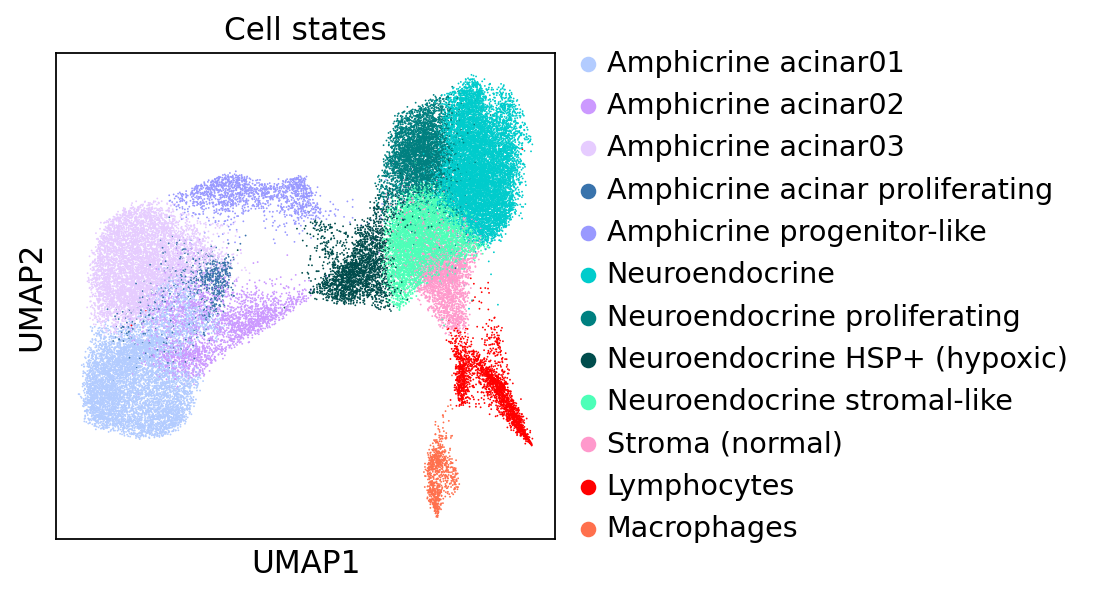

In [2]:
plt.rcParams["figure.figsize"] = (4,4)

sc.pl.umap(adata, color= ['Cell states'], ncols=1)

In [3]:
#Normalize the data:
adata_norm= adata.raw.to_adata()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

In [4]:
#Subset only the panNEC cells:
adata_sub= adata_norm[adata_norm.obs['Cell types']!= "Immune"]
adata_sub.obs['Cell types'].cat.categories

Index(['Neuroendocrine', 'Amphicrine acinar', 'Stroma (normal)'], dtype='object')

In [5]:
#Extract signatures for PBL stemness associated & PDX1 lineage cells:
PBL_stemness= ['PTF1A', 'HNF1A', 'PDX1', 'PBX1', 'MEIS1', 'SOX6', 'BMP4', 'LGR5', 'ID1', 'BIRC5', 'TCF7', 'LEF1', 'IGF2', 'RNF43', 'RSPO4', 'ZNRF3', 'SOX2', 'ONECUT1', 'NEUROG3']
PDX1_high= ['NKX6-3', 'KRT40', 'HAP1', 'CAPN13', 'UNC5D', 'NEFM', 'GLP1R', 'FRMPD2', 'PDX1', 'CNGA3', 'ERICH5', 'SIX2', 'KCNH7', 'OTOP3', 'ASIC2', 'XDH', 'COL22A1', 'EDARADD', 'TMEM53', 'SYT13', 'GJB1', 'NRGN', 'SSTR5', 'TUBB2B', 'ITIH1', 'GRAMD1B', 'FFAR4', 'DNAJC22', 'CDCP1', 'CALCR', 'IL17RE', 'CASZ1', 'RASGRP1', 'CADM1', 'AKR1C4', 'C1orf228', 'FGF9', 'MAP2K6', 'TNR', 'CDHR5', 'LRRC42', 'CECR1', 'PKDCC', 'CLRN3', 'RAB37', 'MED12L', 'SLC17A4', 'MYO7B', 'MT1F', 'HNF4G', 'TUBB2A', 'SLC7A9', 'DIRAS3', 'PRLHR', 'B3GAT1', 'ANK1', 'PCSK6', 'NEUROG3', 'B3GNT3', 'PLXNA2', 'CLMP', 'TMEM132A', 'TCAF2', 'LGALS4', 'MT1E', 'NHLRC4', 'C8A', 'CABP4', 'KRTAP5-8', 'KRTAP5-9', 'PDE2A', 'SMIM22', 'GCNT2', 'SCT', 'EPS8L3', 'KRTAP5-7', 'SEL1L3', 'NAT8L', 'FMO5']

In [6]:
Schlesinger_metaplastic_acinar= ['REG3G', 'REG3A', 'SPINK1', 'GP2', 'ERP27', 'KLK1', 'SERPINA10', 'PTF1A', 'CPA2', 'REG1A', 'CELA3B','NUPR1', 'KRT8', 'PRSS3', 'CUZD1', 'BEX2', 'CABP2', 'RBPJL',
                    'CLDN4', 'CPB1', 'RNASE1', 'CLDN3', 'MUC1', 'EPCAM']


In [8]:
#Compute module scores using three defined signature lists (discussed with Dr. Katharina Detjen): 
sc.tl.score_genes(adata_sub, PDX1_high, score_name= "PDX1 high") 
sc.tl.score_genes(adata_sub, PBL_stemness, score_name= "PBL progenitors") 
sc.tl.score_genes(adata_sub, Schlesinger_metaplastic_acinar, score_name= "Schlesinger Metaplastic acinar") 

Trying to set attribute `.obs` of view, copying.


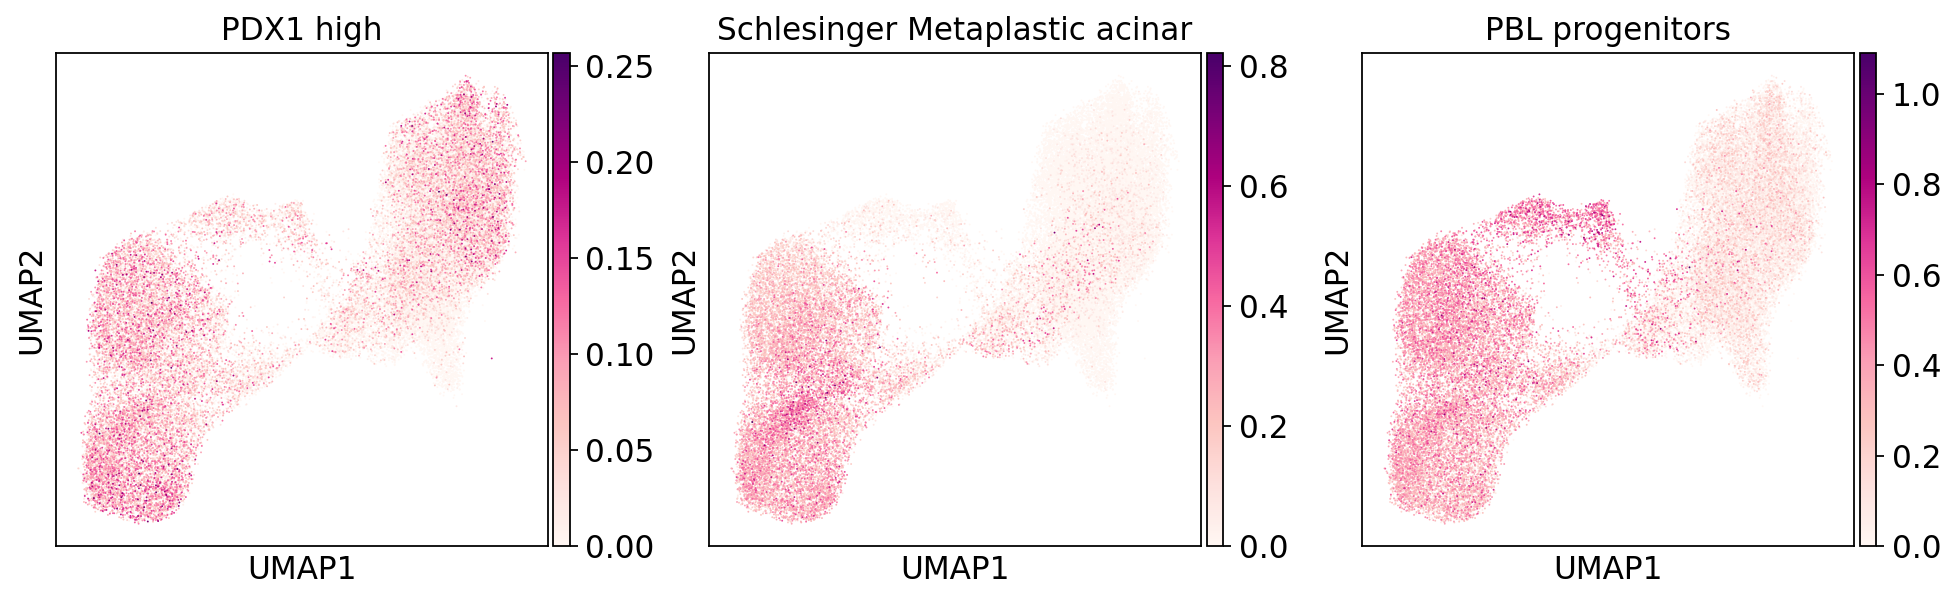

In [9]:
sc.pl.umap(adata_sub, color= ['PDX1 high', 'Schlesinger Metaplastic acinar', 'PBL progenitors'], ncols=3,
          vmin=0, cmap= "RdPu")

#### Supplementary Figure 7C: Visualize three defined signatures for biological contextualization of Amphicrine progenitor-like & acinar clusters. 

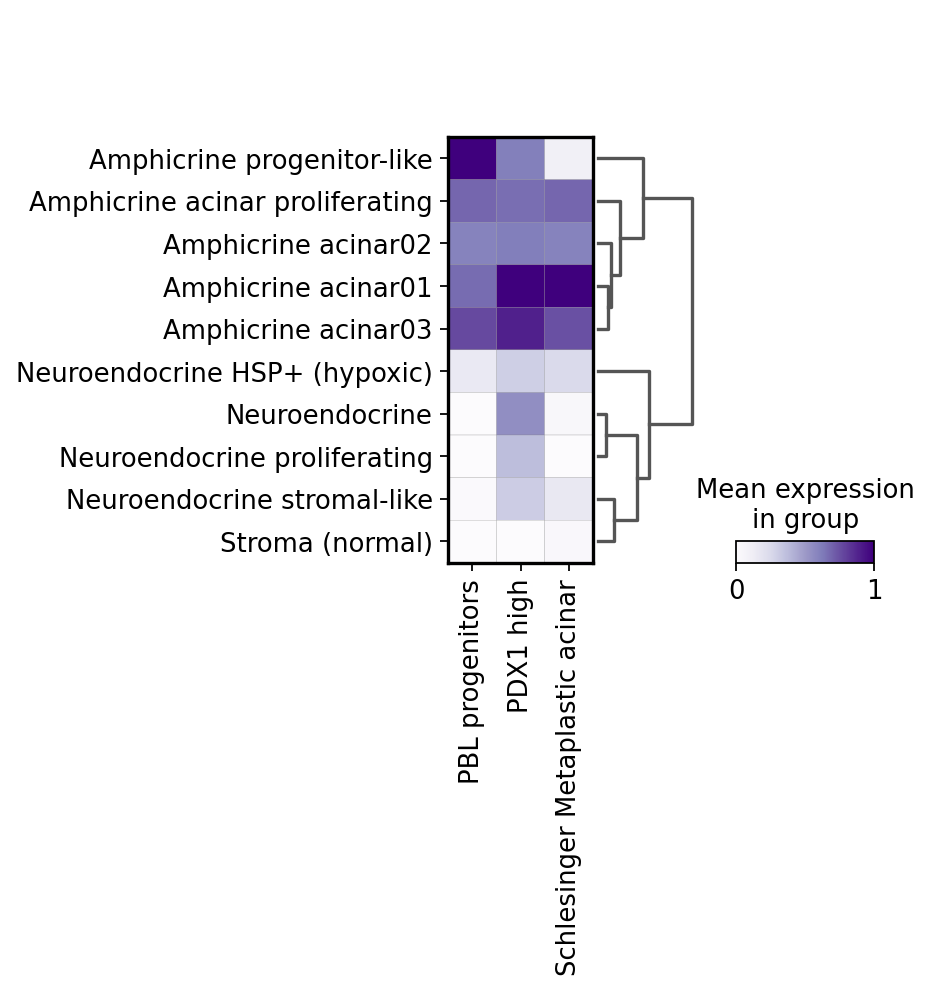

In [10]:
sc.pl.matrixplot(adata_sub, ['PBL progenitors','PDX1 high', 'Schlesinger Metaplastic acinar'], 
                         groupby= "Cell states", dendrogram=True, standard_scale="var", cmap= "Purples",
                         save= "_SupplFigure7C_PBL_PDX1hi_MetaAcinar_scores_v3_16072025.pdf") 

#### PBL signatures:
Consistent with its progenitor characteristics, genes associated with pancreatoblastoma (PBL) — an immature childhood tumor with multilineage features were prominently expressed in this cell state. These genes included LEF1, LGR5, BMP4, ID1, and TCF7 (Supplementary Figure 7a, Supplementary Table 2).

Reference used: Isobe, T. et al. Integrated molecular characterization of the lethal pediatric cancer pancreatoblastoma. Cancer Res. 78, 865–876 (2018). PMID: 29233928

#### PDX1-high signatures: 
Both the Amphicrine acinar01 and Amphicrine acinar03 cell states showed significant enrichment of PDX1-regulated targets, with the highest enrichment observed in Amphicrine acinar01. 

Reference: Yang, X. et al. A PDX1 cistrome and single-cell transcriptome resource of the developing pancreas. Development 149, dev200432 (2022). PMID: 35708349

#### Schlesinger et al. 2020 described a "metaplastic acinar program" in a K-Ras-driven mouse model of acinar-to-ductal metaplasia (ADM) 

Co-expression of metaplastic signatures & acinar enzyme-encoding genes (e.g., CPA1, CPA2, PRSS1/2 etc) in the Amphicrine acinar-01 subgroup suggests an intermediate phenotype that bridges early & late metaplastic states, a feature associated with pancreatic injury and ADM. 

Reference: Schlesinger, Y. et al. Single-cell transcriptomes of pancreatic preinvasive lesions and cancer reveal acinar metaplastic cells' heterogeneity. Nat. Commun. 11, 4516 (2020). PMID: 32908137
